**Description Of the features of the dataset:**

Y – Latitude coordinate of the observation station.
X – Longitude coordinate of the observation station.
data_payload_id – Unique identifier for the data record.
instance_datetime – Timestamp when the data was recorded.
url – URL reference to the data source.
agency – Organization responsible for the data.
platform_type – Type of platform (e.g., station, balloon, etc.).
platform_id – Numeric ID for the platform.
platform_name – Name of the observation platform or station.
gaw_id – Global Atmosphere Watch ID of the platform.
instrument_name – Name of the instrument used for measurement.
instrument_model – Model of the instrument.
instrument_number – Instrument's identification number.
monthly_date – Date associated with monthly aggregated data.
monthly_columno3 – Monthly average ozone column value.
monthly_stddevo3 – Standard deviation of the monthly ozone values.
monthly_npts – Number of observations used in monthly average.
daily_date – Date of the daily observation.
daily_wlcode – Wavelength code used during observation.
daily_obscode – Observation code (e.g., method or technique).
daily_columno3 – Daily ozone column measurement (Dobson Units).
daily_stddevo3 – Standard deviation of the daily ozone value.
daily_utc_begin – UTC time when observation began.
daily_utc_end – UTC time when observation ended.
daily_utc_mean – Mean UTC time of observation.
daily_nobs – Number of observations for that day.
daily_mmu – Measurement uncertainty for daily ozone.
daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.
latest_observation – Flag indicating if this is the most recent data (0 or 1).
country – Country of the observation station.
scientific_authority – Name of the responsible scientist or authority.
version – Version number of the data record.

In [1]:
%pip install optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import optuna
from optuna.samplers import TPESampler



Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [11]:
df=pd.read_csv('result _2.csv')
df.head()


C:\Users\T2430513\AppData\Local\Temp\ipykernel_8780\226454534.py:1: DtypeWarning: Columns (19,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('result _2.csv')


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,43.781,-79.468,2260788,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.6,19.3,17.4,22.0,2.7,-6.7,0,CAN,Vitali Fioletov,4.15
1,43.781,-79.468,2260768,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.1,19.6,17.2,21.0,2.8,-4.9,0,CAN,Vitali Fioletov,4.15
2,43.781,-79.468,2260775,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.0,18.9,17.7,15.0,2.7,-3.3,0,CAN,Vitali Fioletov,4.15
3,43.781,-79.468,2260778,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,17.5,19.5,18.5,11.0,2.9,0.9,0,CAN,Vitali Fioletov,4.15
4,58.739,-94.074,2260790,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,77,Churchill,CHL,...,13.9,13.9,13.9,1.0,1.7,-3.5,0,CAN,Vitali Fioletov,4.16


In [12]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2023-12-30,391.7
1,2023-12-10,345.1
2,2023-12-17,336.0
3,2023-12-20,341.5
4,2023-12-01,378.6


In [13]:
# df['daily_date'] = pd.to_datetime(df['daily_date'], format='%d-%m-%y')

# 2. Sort the dataframe by the full date (oldest to latest)
scaler = MinMaxScaler()
df['daily_columno3'] = scaler.fit_transform(df[['daily_columno3']])
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (7-day)
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 121):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
print(df.shape)
df.head()


(192308, 126)


C:\Users\T2430513\AppData\Local\Temp\ipykernel_8780\201707771.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
C:\Users\T2430513\AppData\Local\Temp\ipykernel_8780\201707771.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
C:\Users\T2430513\AppData\Local\Temp\ipykernel_8780\201707771.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag111,lag112,lag113,lag114,lag115,lag116,lag117,lag118,lag119,lag120
120,1957-08-08,0.336129,0.352578,0.051380,0.351546,0.044934,0.316285,0.388093,0.372136,0.324264,...,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835,0.405892
121,1957-08-08,0.324264,0.355953,0.048757,0.348743,0.041124,0.336129,0.316285,0.388093,0.372136,...,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835
122,1957-08-08,0.399959,0.342594,0.033715,0.344292,0.038507,0.324264,0.336129,0.316285,0.388093,...,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938
123,1957-08-09,0.266367,0.353355,0.033063,0.354414,0.041538,0.399959,0.324264,0.336129,0.316285,...,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023
124,1957-08-09,0.336129,0.345172,0.043088,0.338405,0.051894,0.266367,0.399959,0.324264,0.336129,...,0.378069,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069


In [14]:

lag_features = [f'lag{i}' for i in range(1, 121)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


Tuning Linear Regression...


[I 2025-06-04 16:30:30,198] A new study created in memory with name: no-name-56742fbe-4114-401e-a1f0-c5969a87494c



Tuning Decision Tree...


[I 2025-06-04 16:30:34,161] Trial 0 finished with value: 0.004736918781867697 and parameters: {'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.004736918781867697.
[I 2025-06-04 16:30:40,651] Trial 1 finished with value: 0.004851004974846706 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.004736918781867697.
[I 2025-06-04 16:30:43,802] Trial 2 finished with value: 0.004754790955489303 and parameters: {'max_depth': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.004736918781867697.
[I 2025-06-04 16:30:46,150] Trial 3 finished with value: 0.004837438281610195 and parameters: {'max_depth': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.004736918781867697.
[I 2025-06-04 16:30:51,768] Trial 4 finished with value: 0.004795226474309614 and parameters: {'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.004736918781867697.
[I 2025-06-04 16:30:54,100] Trial 5 finished with value: 0.0048374382

Decision Tree Best Params: {'max_depth': 5, 'min_samples_split': 10}


...

MLP Regressor Best Params: {'hidden_layer_sizes': (50, 50), 'alpha': 0.0020941818266537143, 'learning_rate_init': 0.04373182348324877}


[I 2025-06-07 06:51:47,218] A new study created in memory with name: no-name-f1eac27d-d898-466e-919e-5a343be7ffb0



Tuning K-Neighbors Regressor...


[I 2025-06-07 06:51:49,997] Trial 0 finished with value: 0.005216506464672712 and parameters: {'n_neighbors': 5}. Best is trial 0 with value: 0.005216506464672712.
[I 2025-06-07 06:51:52,694] Trial 1 finished with value: 0.00499457046752929 and parameters: {'n_neighbors': 10}. Best is trial 1 with value: 0.00499457046752929.
[I 2025-06-07 06:51:55,350] Trial 2 finished with value: 0.005049556327267902 and parameters: {'n_neighbors': 8}. Best is trial 1 with value: 0.00499457046752929.
[I 2025-06-07 06:51:58,083] Trial 3 finished with value: 0.0050873513921629535 and parameters: {'n_neighbors': 7}. Best is trial 1 with value: 0.00499457046752929.
[I 2025-06-07 06:52:00,809] Trial 4 finished with value: 0.00549333368601698 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.00499457046752929.
[I 2025-06-07 06:52:03,486] Trial 5 finished with value: 0.00549333368601698 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.00499457046752929.
[I 2025-06-07 06:52:06

K-Neighbors Regressor Best Params: {'n_neighbors': 10}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.068
MAE : 0.051
R2  : 56.88 %

----- Decision Tree -----
RMSE: 0.069
MAE : 0.052
R2  : 55.53 %

----- Random Forest -----
RMSE: 0.068
MAE : 0.051
R2  : 56.60 %

----- Gradient Boosting -----
RMSE: 0.068
MAE : 0.051
R2  : 56.82 %

----- SVR -----
RMSE: 0.073
MAE : 0.055
R2  : 50.10 %

----- AdaBoost Regressor -----
RMSE: 0.069
MAE : 0.052
R2  : 55.36 %

----- MLP Regressor -----
RMSE: 0.070
MAE : 0.053
R2  : 53.81 %

----- K-Neighbors Regressor -----
RMSE: 0.071
MAE : 0.053
R2  : 53.11 %



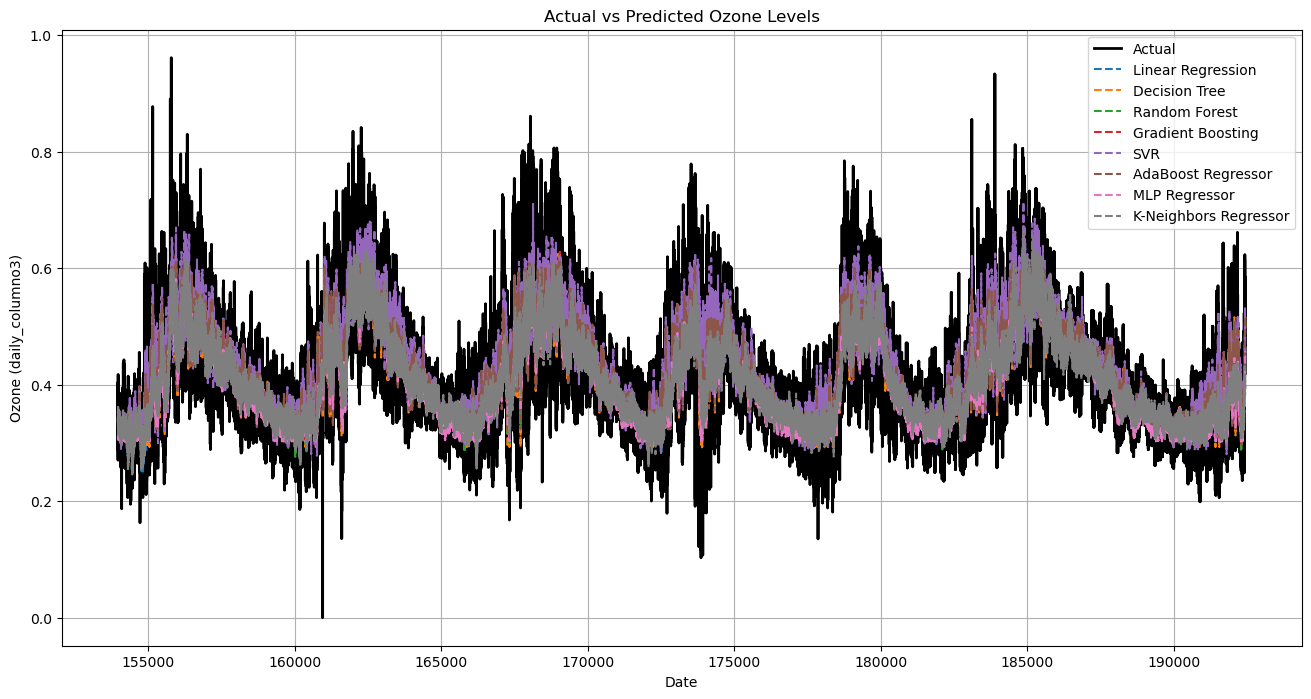

In [15]:

param_spaces = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': ('int', 3, 10),
        'min_samples_split': ('int', 2, 10),
    },
    'Random Forest': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 10),
    },
    'Gradient Boosting': {
        'n_estimators': ('int', 50, 200),
        'learning_rate': ('float', 0.01, 0.3),
        'max_depth': ('int', 3, 7),
    },
    'SVR': {
        'C': ('float', 0.1, 10),
        'epsilon': ('float', 0.01, 1.0),
    },
    'AdaBoost Regressor': {
        'n_estimators': ('int', 50, 150),
        'learning_rate': ('float', 0.01, 1.0),
    },
    'MLP Regressor': {
        'hidden_layer_sizes': ('cat', [(50,), (100,), (50, 50)]),
        'alpha': ('float', 0.0001, 0.01),
        'learning_rate_init': ('float', 0.001, 0.05),
    },
    'K-Neighbors Regressor': {
        'n_neighbors': ('int', 2, 10),
    }
}

# ----------- STEP 4: Models Dictionary ----------- #
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'SVR': SVR,
    'AdaBoost Regressor': AdaBoostRegressor,
    'MLP Regressor': MLPRegressor,
    'K-Neighbors Regressor': KNeighborsRegressor,
}

# ----------- STEP 5: Suggestion Utility ----------- #
def suggest(trial, name, dist):
    if isinstance(dist, tuple) and dist[0] == 'int':
        return trial.suggest_int(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'float':
        return trial.suggest_float(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'cat':
        return trial.suggest_categorical(name, dist[1])
    else:
        raise ValueError(f"Unsupported distribution type for {name}: {dist}")

# ----------- STEP 6: Model Tuning Function ----------- #
def tune_model(name, model_class, param_space, n_trials=10):
    if not param_space:
        return model_class()

    def objective(trial):
        params = {key: suggest(trial, key, dist) for key, dist in param_space.items()}
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = mean_squared_error(y_test, preds)
        return rmse

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    print(f"{name} Best Params: {study.best_params}")
    return model_class(**study.best_params)

# ----------- STEP 7: Tuning and Evaluation ----------- #
results = {}
best_models = {}

for name in model_classes:
    print(f"\nTuning {name}...")
    model = tune_model(name, model_classes[name], param_spaces.get(name, {}), n_trials=20)
    model.fit(X_train, y_train)
    best_models[name] = model

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Predictions': preds,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# ----------- STEP 8: Print Metrics ----------- #
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2'] * 100):.2f} %\n")

# ----------- STEP 9: Plot Predictions ----------- #
plt.figure(figsize=(16, 8))
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
for name, res in results.items():
    plt.plot(y_test.index, res['Predictions'], label=name, linestyle='--')
plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Date')
plt.ylabel('Ozone (daily_columno3)')
plt.legend()
plt.grid(True)
plt.show()